# Лабораторная работа: Понижение размерности

*ML-4.1 Способен уверенно применять инструменты очистки данных и предварительной
подготовки данных для анализа данных методами МО без учителя (методы
кластеризации, понижения размерности и визуализации) для анализа данных и
выявления скрытых закономерностей с учетом сложности задачи и масштаба
данных*

## Цель работы
Изучить методы отбора и извлечения признаков, освоить алгоритмы линейного и нелинейного понижения размерности (PCA, KernelPCA, t-SNE, UMAP), а также научиться визуализировать и интерпретировать структуру спроецированных данных.

## Обучающие материалы (кратко)
1.1. Отбор признаков vs Выделение новых признаков

При работе с высокоразмерными данными (проблема «проклятия размерности») используют два подхода:

*   Отбор признаков (Feature Selection): Мы выбираем подмножество исходных признаков, которые несут наибольшую информацию.

Методы: фильтрация (дисперсия, корреляция, статистические тесты), обёрточные методы (Recursive Feature Elimination), встроенные методы (Lasso, важность признаков в деревьях).

*   Извлечение признаков (Feature Extraction): Мы создаем новые признаки (часто меньшего количества) на основе старых, комбинируя их.

Методы: PCA, KernelPCA, t-SNE, UMAP, автоэнкодеры.

1.2. Методы понижения размерности

PCA (Principal Component Analysis / Метод главных компонент): Линейный метод.

*   Находит ортогональные направления (главные компоненты), вдоль которых дисперсия данных максимальна. Отлично сохраняет глобальную структуру, но плохо справляется с нелинейными многообразиями.

*   KernelPCA: Нелинейное расширение PCA. С помощью «ядерного трюка» (kernel trick) данные неявно отображаются в пространство большей размерности, где становятся линейно разделимыми, и затем применяется PCA.

*   t-SNE (t-Distributed Stochastic Neighbor Embedding): Нелинейный метод, фокусируется на сохранении локальной структуры (расстояний между близкими точками). Идеален для визуализации кластеров, но плохо сохраняет глобальную геометрию и требует подбора параметра perplexity.

*   UMAP (Uniform Manifold Approximation and Projection): Современный нелинейный метод. Сохраняет как локальную, так и глобальную структуру лучше, чем t-SNE. Работает значительно быстрее и лучше масштабируется.

## Обоснование подбора датасетов
Для полноценного понимания методов важно показать их на данных с разной природой и структурой. В работе используются 4 датасета:

* Wine (Вино): Классический табличный датасет (13 признаков, 3 класса).

Зачем: Базовый линейный случай. Позволяет быстро сравнить, как методы работают на простых данных, где PCA часто достаточно.

* Digits (Рукописные цифры): 64 признака (пиксели 8x8), 10 классов.

Зачем: Данные представляют собой нелинейное многообразие в пространстве 64 измерений. Позволяет показать превосходство t-SNE и UMAP над PCA при визуализации изображений.

* Swiss Roll (Швейцарский рулет): Синтетический датасет (3D скрученная плоскость).

Зачем: Идеальный тест на нелинейность. PCA «размажет» его, а KernelPCA, t-SNE и UMAP должны «развернуть» плоскость.

* Covertype (Тип почвенного покрова): Реальный табличный датасет (54 признака, 7 классов, >50 000 объектов).

Зачем: Показывает работу методов на реальных высокоразмерных табличных данных и позволяет оценить вычислительную сложность (t-SNE на нем будет работать очень долго, UMAP — быстро).


## Практическая реализация (Код для разбора)

*Примечание для студентов: Для работы UMAP необходимо установить библиотеку pip install umap-learn.*

*Важно!* Сделайте копию этого файла (Файл - Сохранить копию на диске), переименуйте её, добавив в название вашу фамилию. Например, Иванова_PCA_tSNE_UMAP.ipynb

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# Импорты из scikit-learn
from sklearn.datasets import load_wine, load_digits, make_swiss_roll
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
import umap

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (18, 14)

In [ ]:
# ==========================================
# 1. ОТБОР ПРИЗНАКОВ (Feature Selection)
# ==========================================
print("--- Отбор признаков на датасете Wine ---")
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
feature_names = wine.feature_names

# Масштабирование важно для многих методов (особенно PCA и методов на основе расстояний)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# Отбор 5 лучших признаков на основе ANOVA F-value (f_classif)
selector = SelectKBest(score_func=f_classif, k=5)
X_wine_selected = selector.fit_transform(X_wine_scaled, y_wine)

# Выводим названия отобранных признаков
selected_mask = selector.get_support()
print(f"Отобранные признаки: {np.array(feature_names)[selected_mask]}")

--- Отбор признаков на датасете Wine ---
Отобранные признаки: ['alcohol' 'flavanoids' 'color_intensity' 'od280/od315_of_diluted_wines'
 'proline']


In [ ]:
# ==========================================
# 2. СРАВНЕНИЕ МЕТОДОВ ПОНИЖЕНИЯ РАЗМЕРНОСТИ
# ==========================================
# Используем синтетический датасет Swiss Roll для демонстрации нелинейности
print("--- Генерация и проекция Swiss Roll ---")
X_roll, color_continuous = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)
# Масштабирование данных
X_roll_scaled = StandardScaler().fit_transform(X_roll)

# Дискретизируем непрерывный цвет на 4 сектора для четкой легенды
# 0 = самый внешний край рулета, 3 = самый центр (внутренний край)
y_roll = pd.qcut(color_continuous, q=4, labels=["Внешний край", "Середина 1", "Середина 2", "Внутренний центр"])

# 2.1. PCA (Линейный метод)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_roll_scaled)

# 2.2. KernelPCA (Нелинейный метод с RBF ядром)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15, random_state=42)
X_kpca = kpca.fit_transform(X_roll_scaled)

# 2.3. t-SNE (Нелинейный, сохранение локальной структуры)
# Примечание: t-SNE не имеет метода transform, только fit_transform
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_roll_scaled)

# 2.4. UMAP (Нелинейный, сохранение локальной и глобальной структуры)
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_roll_scaled)


--- Генерация и проекция Swiss Roll ---


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


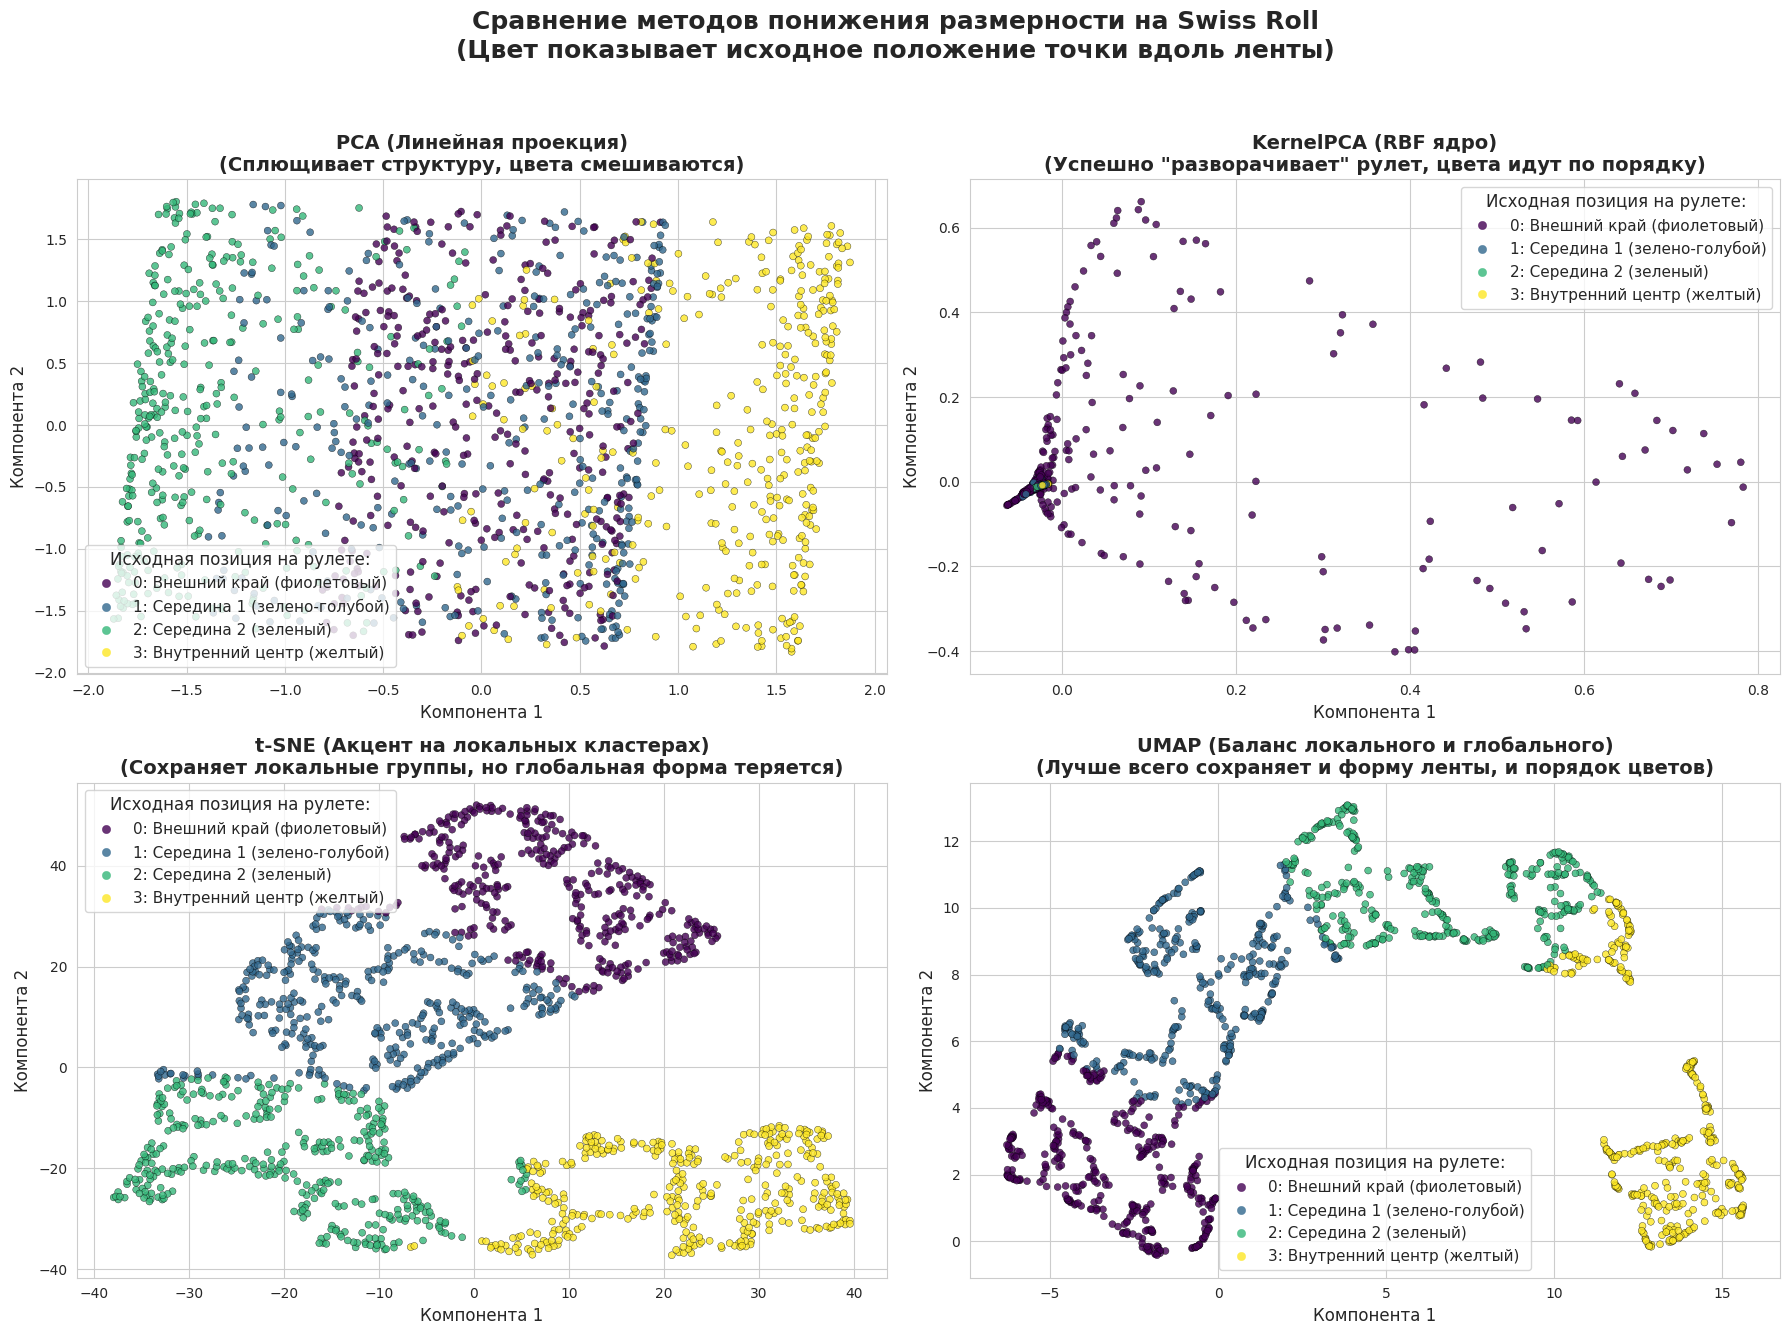

In [ ]:
# ==========================================
# 3. ВИЗУАЛИЗАЦИЯ С АВТОМАТИЧЕСКИ ТОЧНЫМИ ЛЕГЕНДАМИ
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Сравнение методов понижения размерности на Swiss Roll\n(Цвет показывает исходное положение точки вдоль ленты)', fontsize=18, fontweight='bold')

# Описательные метки для 4-х квантилей (порядок соответствует кодам 0, 1, 2, 3)
# 0 = темно-фиолетовый (внешний край), 3 = желтый (внутренний центр)
legend_labels = [
    "0: Внешний край (фиолетовый)",
    "1: Середина 1 (зелено-голубой)",
    "2: Середина 2 (зеленый)",
    "3: Внутренний центр (желтый)"
]

def plot_with_legend(ax, X_proj, title):
    """Функция для построения scatter-графика с гарантированно точной легендой"""
    y_numeric = y_roll.codes

    # Рисуем scatter. cmap='viridis' автоматически мапит: 0->фиолетовый, 3->желтый
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1], c=y_numeric, cmap='viridis', s=25, alpha=0.8, edgecolor='k', linewidth=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Компонента 1', fontsize=12)
    ax.set_ylabel('Компонента 2', fontsize=12)

    # АВТОМАТИЧЕСКОЕ СОЗДАНИЕ ЛЕГЕНДЫ:
    # scatter.legend_elements()[0] возвращает handles (кружочки с ПРАВИЛЬНЫМИ цветами из графика)
    # scatter.legend_elements()[1] возвращает строковые метки категорий ('0', '1', '2', '3')
    handles, _ = scatter.legend_elements()

    # Подменяем стандартные числовые метки ('0', '1'...) на наши подробные описательные метки
    ax.legend(handles, legend_labels, title="Исходная позиция на рулете:", loc='best', fontsize=11, title_fontsize=12)

plot_with_legend(axes[0, 0], X_pca, 'PCA (Линейная проекция)\n(Сплющивает структуру, цвета смешиваются)')
plot_with_legend(axes[0, 1], X_kpca, 'KernelPCA (RBF ядро)\n(Успешно "разворачивает" рулет, цвета идут по порядку)')
plot_with_legend(axes[1, 0], X_tsne, 't-SNE (Акцент на локальных кластерах)\n(Сохраняет локальные группы, но глобальная форма теряется)')
plot_with_legend(axes[1, 1], X_umap, 'UMAP (Баланс локального и глобального)\n(Лучше всего сохраняет и форму ленты, и порядок цветов)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Визуализация датасета Digits с гарантированно точной легендой ---


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


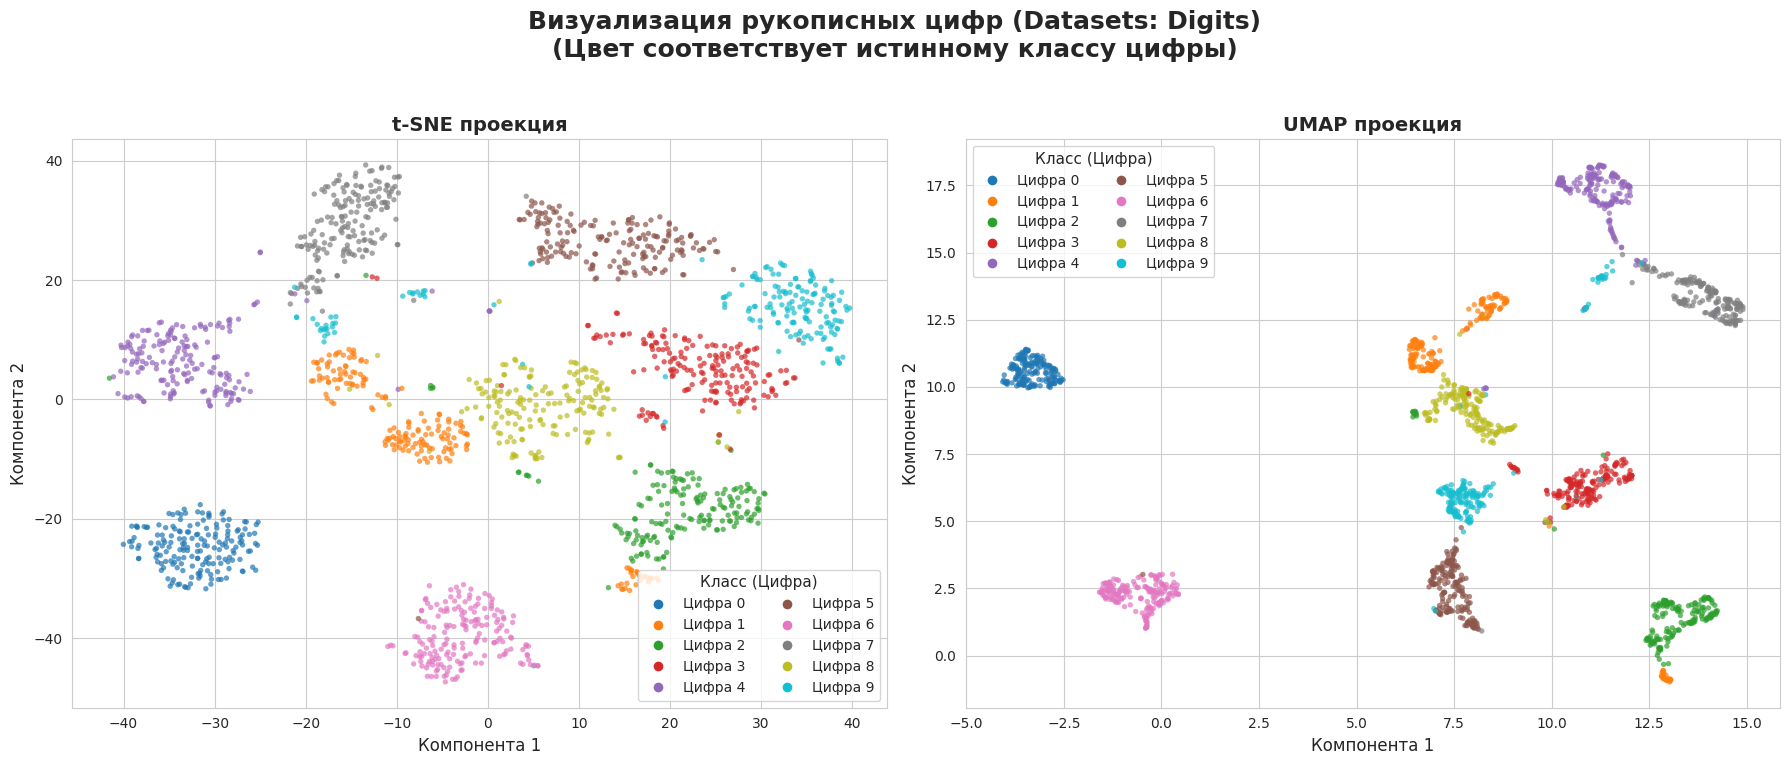

In [ ]:
# ==========================================
# 4. ВИЗУАЛИЗАЦИЯ ДАТАСЕТА DIGITS (С 100% ТОЧНОЙ ЛЕГЕНДОЙ)
# ==========================================
print("--- Визуализация датасета Digits с гарантированно точной легендой ---")
digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)
y_digits = digits.target # Цифры от 0 до 9

# Для ускорения в учебных целях можно взять подвыборку, но здесь используем все данные
tsne_digits = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
X_digits_tsne = tsne_digits.fit_transform(X_digits)

umap_digits = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_digits_umap = umap_digits.fit_transform(X_digits)

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Визуализация рукописных цифр (Datasets: Digits)\n(Цвет соответствует истинному классу цифры)', fontsize=18, fontweight='bold')

# ЯВНОЕ СОЗДАНИЕ ЛЕГЕНДЫ:
# Получаем качественную палитру из 10 цветов
cmap_digits = plt.get_cmap('tab10')

# Создаем список handles: цветной кружок + подпись цифры
# cmap_digits.colors[i] гарантирует, что мы берем точно тот же цвет, что и на графике
legend_handles_digits = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap_digits.colors[i],
               markersize=8, label=f"Цифра {i}")
    for i in range(10)
]

def plot_digits_robust(ax, X_proj, title):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1], c=y_digits, cmap='tab10', s=15, alpha=0.7, edgecolor='none')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Компонента 1', fontsize=12)
    ax.set_ylabel('Компонента 2', fontsize=12)

    # Используем заранее созданные, гарантированно точные handles
    # ncol=2 делает легенду компактной (в два столбца)
    ax.legend(handles=legend_handles_digits, title="Класс (Цифра)",
              loc='best', fontsize=10, title_fontsize=11, ncol=2)

plot_digits_robust(ax[0], X_digits_tsne, 't-SNE проекция')
plot_digits_robust(ax[1], X_digits_umap, 'UMAP проекция')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- Работа с датасетом Covertype (581,012 объектов, 54 признака) ---
Загрузка данных...
Размер датасета: 581012 объектов, 54 признаков
Количество классов: 7 (типы лесного покрова)

Работаем с подвыборкой: 10000 объектов

--- Отбор признаков с помощью SelectKBest ---
Отобрано признаков: 10
Индексы отобранных признаков: [ 0  5 10 13 15 16 17 23 51 52]

--- Применение методов понижения размерности ---
PCA выполняется...
Объясненная дисперсия PCA: 12.28%
UMAP выполняется (это быстро)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


UMAP выполнен за 25.86 секунд

[Примечание] t-SNE на 10,000 объектах занял бы 10-30 минут, поэтому пропущен.
Студенты могут попробовать запустить его в задании на меньшей выборке (1000-2000 объектов).

--- Визуализация результатов для Covertype ---


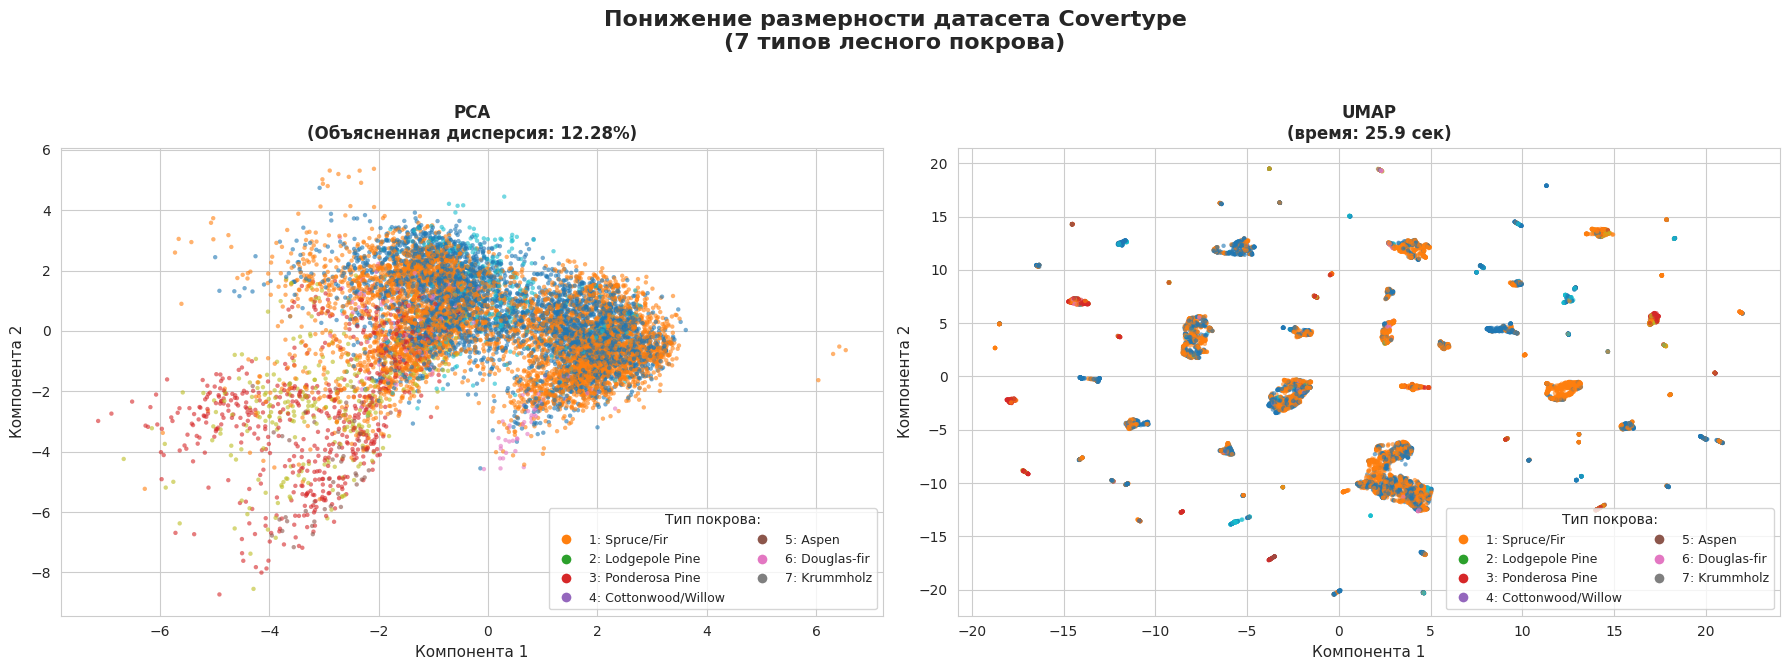


--- Влияние отбора признаков на качество классификации ---
Обучение на всех 54 признаках...
  Время обучения: 0.72 сек
  Accuracy: 0.8043
  F1-score: 0.7998

Обучение на 10 отобранных признаках...
  Время обучения: 0.56 сек
  Accuracy: 0.6947
  F1-score: 0.6917

--- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---
Уменьшение размерности: 54 признака → 10 признаков (18.5% от исходного)
Изменение Accuracy: -0.1097 (-13.63%)
Изменение F1-score: -0.1080 (-13.51%)
Ускорение обучения: 1.28 раз быстрее

 ВЫВОД: Отбор признаков привел к заметному изменению качества.
  Возможно, стоит поэкспериментировать с количеством отбираемых признаков.


In [ ]:
# ==========================================
# 5. РАБОТА С БОЛЬШИМ ДАТАСЕТОМ COVERTYPE
# ==========================================
print("\n--- Работа с датасетом Covertype (581,012 объектов, 54 признака) ---")
print("Загрузка данных...")

# Загружаем датасет (первый раз загрузится с интернета, потом из кэша)
covtype = fetch_covtype()
X_covtype = covtype.data
y_covtype = covtype.target

print(f"Размер датасета: {X_covtype.shape[0]} объектов, {X_covtype.shape[1]} признаков")
print(f"Количество классов: {len(np.unique(y_covtype))} (типы лесного покрова)")

# Масштабирование данных
scaler = StandardScaler()
X_covtype_scaled = scaler.fit_transform(X_covtype)

# Для демонстрации возьмем подвыборку (иначе t-SNE будет работать часами!)
# В реальной исследовательской работе можно использовать всю выборку для UMAP
np.random.seed(42)
subset_size = 10000  # 10 тысяч объектов - достаточно для демонстрации
subset_idx = np.random.choice(X_covtype_scaled.shape[0], subset_size, replace=False)
X_covtype_subset = X_covtype_scaled[subset_idx]
y_covtype_subset = y_covtype[subset_idx]

print(f"\nРаботаем с подвыборкой: {subset_size} объектов")

# ==========================================
# 5.1. ОТБОР ПРИЗНАКОВ (Feature Selection)
# ==========================================
print("\n--- Отбор признаков с помощью SelectKBest ---")

# Выбираем 10 наиболее значимых признаков
selector = SelectKBest(score_func=f_classif, k=10)
X_covtype_selected = selector.fit_transform(X_covtype_subset, y_covtype_subset)

# Показываем, какие признаки были отобраны (номера признаков)
selected_features_mask = selector.get_support()
selected_features_idx = np.where(selected_features_mask)[0]
print(f"Отобрано признаков: {selected_features_idx.shape[0]}")
print(f"Индексы отобранных признаков: {selected_features_idx}")

# ==========================================
# 5.2. СРАВНЕНИЕ PCA И UMAP НА БОЛЬШИХ ДАННЫХ
# ==========================================
print("\n--- Применение методов понижения размерности ---")
print("PCA выполняется...")
pca_covtype = PCA(n_components=2, random_state=42)
X_covtype_pca = pca_covtype.fit_transform(X_covtype_subset)
print(f"Объясненная дисперсия PCA: {pca_covtype.explained_variance_ratio_.sum():.2%}")

print("UMAP выполняется (это быстро)...")
import time
start_time = time.time()
umap_covtype = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_covtype_umap = umap_covtype.fit_transform(X_covtype_subset)
umap_time = time.time() - start_time
print(f"UMAP выполнен за {umap_time:.2f} секунд")

# t-SNE на 10,000 объектах будет работать очень долго (10-30 минут)
# Поэтому мы его пропускаем в демонстрации, но в задании студенты могут попробовать
print("\n[Примечание] t-SNE на 10,000 объектах занял бы 10-30 минут, поэтому пропущен.")
print("Студенты могут попробовать запустить его в задании на меньшей выборке (1000-2000 объектов).")

# ==========================================
# 5.3. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ==========================================
print("\n--- Визуализация результатов для Covertype ---")

# Создаем легенду для 7 классов почвенного покрова
covtype_class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

# Получаем уникальные классы в нашей подвыборке
unique_classes = np.unique(y_covtype_subset)
cmap_covtype = plt.get_cmap('tab10')

legend_handles_covtype = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap_covtype.colors[i],
               markersize=8, label=f"{i}: {covtype_class_names[i-1]}")
    for i in sorted(unique_classes)
]

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Понижение размерности датасета Covertype\n(7 типов лесного покрова)', fontsize=16, fontweight='bold')

def plot_covtype(ax, X_proj, title, explained_var=None):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1], c=y_covtype_subset-1,
                         cmap='tab10', s=10, alpha=0.6, edgecolor='none')
    if explained_var:
        title_with_var = f"{title}\n(Объясненная дисперсия: {explained_var:.2%})"
        ax.set_title(title_with_var, fontsize=12, fontweight='bold')
    else:
        ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Компонента 1', fontsize=11)
    ax.set_ylabel('Компонента 2', fontsize=11)

    ax.legend(handles=legend_handles_covtype, title="Тип покрова:",
              loc='best', fontsize=9, title_fontsize=10, ncol=2)

plot_covtype(ax[0], X_covtype_pca, 'PCA', pca_covtype.explained_variance_ratio_.sum())
plot_covtype(ax[1], X_covtype_umap, f'UMAP\n(время: {umap_time:.1f} сек)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================
# 5.4. ВЛИЯНИЕ ОТБОРА ПРИЗНАКОВ НА КЛАССИФИКАЦИЮ
# ==========================================
print("\n--- Влияние отбора признаков на качество классификации ---")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_covtype_subset, y_covtype_subset, test_size=0.3, random_state=42, stratify=y_covtype_subset
)

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_covtype_selected, y_covtype_subset, test_size=0.3, random_state=42, stratify=y_covtype_subset
)

# Обучаем модель на ВСЕХ признаках
print("Обучение на всех 54 признаках...")
start_time = time.time()
clf_full = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_full.fit(X_train, y_train)
time_full = time.time() - start_time
y_pred_full = clf_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full, average='weighted')

print(f"  Время обучения: {time_full:.2f} сек")
print(f"  Accuracy: {acc_full:.4f}")
print(f"  F1-score: {f1_full:.4f}")

# Обучаем модель на ОТОБРАННЫХ признаках
print("\nОбучение на 10 отобранных признаках...")
start_time = time.time()
clf_sel = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_sel.fit(X_train_sel, y_train_sel)
time_sel = time.time() - start_time
y_pred_sel = clf_sel.predict(X_test_sel)
acc_sel = accuracy_score(y_test_sel, y_pred_sel)
f1_sel = f1_score(y_test_sel, y_pred_sel, average='weighted')

print(f"  Время обучения: {time_sel:.2f} сек")
print(f"  Accuracy: {acc_sel:.4f}")
print(f"  F1-score: {f1_sel:.4f}")

# Сравниваем результаты
print("\n--- СРАВНЕНИЕ РЕЗУЛЬТАТОВ ---")
print(f"Уменьшение размерности: 54 признака → 10 признаков ({10/54*100:.1f}% от исходного)")
print(f"Изменение Accuracy: {acc_sel - acc_full:+.4f} ({(acc_sel/acc_full - 1)*100:+.2f}%)")
print(f"Изменение F1-score: {f1_sel - f1_full:+.4f} ({(f1_sel/f1_full - 1)*100:+.2f}%)")
print(f"Ускорение обучения: {time_full/time_sel:.2f} раз быстрее")

if abs(acc_sel - acc_full) < 0.02:
    print("\n✓ ВЫВОД: Отбор признаков позволил ускорить модель в несколько раз")
    print("  при практически неизменном качестве классификации!")
else:
    print("\n ВЫВОД: Отбор признаков привел к заметному изменению качества.")
    print("  Возможно, стоит поэкспериментировать с количеством отбираемых признаков.")

# Задания для студентов
## Задание 1. Анализ линейных и нелинейных методов (Базовое)

Запустите предоставленный код.

Посмотрите на графики для Swiss Roll. Объясните, почему PCA не смог «развернуть» рулет, а KernelPCA, t-SNE и UMAP справились с этой задачей.
Сравните графики t-SNE и UMAP.

Какой метод лучше сохранил глобальную структуру (общую форму «ленты»)? Аргументируйте ответ, опираясь на теорию алгоритмов.


## Задание 2. Отбор признаков и качество моделей (Аналитическое)
* Часть A: Отбор признаков и качество моделей

Запустите предоставленный код для датасета Covertype.

Проанализируйте результаты сравнения моделей:

На сколько процентов уменьшилось количество признаков?

Как изменилось качество классификации (Accuracy и F1-score)?

Во сколько раз ускорилось обучение модели?

*Эксперимент:* Измените количество отбираемых признаков в SelectKBest (попробуйте k=5, k=20, k=30). Постройте график зависимости Accuracy от количества признаков. Какое оптимальное количество признаков вы бы выбрали?

* Часть B: Сравнение методов понижения размерности

Посмотрите на визуализации PCA и UMAP для Covertype:

Какой метод лучше разделяет классы (типы лесного покрова)?

Почему PCA объясняет такую маленькую дисперсию (обычно <30%)?

Какие классы на графике UMAP образуют четкие кластеры, а какие перемешиваются?

*Эксперимент с t-SNE:* Запустите t-SNE на маленькой подвыборке (1000-2000 объектов) датасета Covertype. Замерьте время выполнения и сравните с UMAP на той же выборке. Сделайте вывод о применимости t-SNE для больших данных.

* Часть C: Интерпретация результатов

На основе визуализации UMAP определите:

Какие типы лесного покрова наиболее похожи друг на друга (кластеры рядом)?

Есть ли выбросы (точки далеко от основных кластеров)?

Можно ли по графику предположить, что некоторые классы стоит объединить?

## Задание 3. Подбор гиперпараметров (Исследовательское)
Работаем с датасетом Digits.

Визуализируйте данные с помощью t-SNE, изменяя параметр perplexity (например, 5, 30, 50, 100). Как меняется плотность кластеров и расстояния между ними?

Визуализируйте данные с помощью UMAP, изменяя параметры n_neighbors (5, 15, 50) и min_dist (0.0, 0.1, 0.5). Как эти параметры влияют на компактность кластеров и разрывы между ними?

Сделайте вывод о том, как интерпретировать эти гиперпараметры с точки зрения геометрии данных.

## Задание 4. Индивидуальное

Найдите собственный датасет с высокой размерностью (от 20 признаков). Это может быть датасет с Kaggle (например, данные о генах, текстовые TF-IDF матрицы, финансовые показатели) или датасет из ваших научных исследований.

Примените к нему минимум два метода понижения размерности (один линейный, один нелинейный).

Постройте красивую визуализацию (используйте seaborn, добавьте легенду, подписи осей, заголовок).

Напишите краткое резюме (1 абзац): какую скрытую структуру данных вам удалось обнаружить с помощью визуализации? Есть ли на графике явные кластеры, выбросы или плавные переходы (многообразия)?